#### **CNN Architecture**

A **Convolutional Neural Network (CNN)** is a deep learning architecture mainly used for **image processing and computer vision**. The basic idea is:

> **Image → Extract features → Reduce size → Classify**

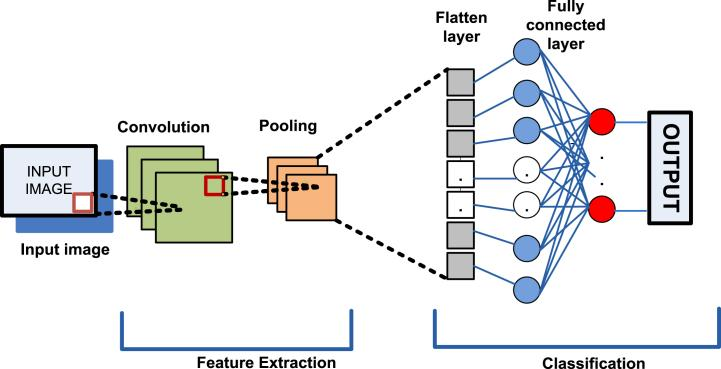

#### **Basic CNN Architecture**

A typical CNN looks like this:

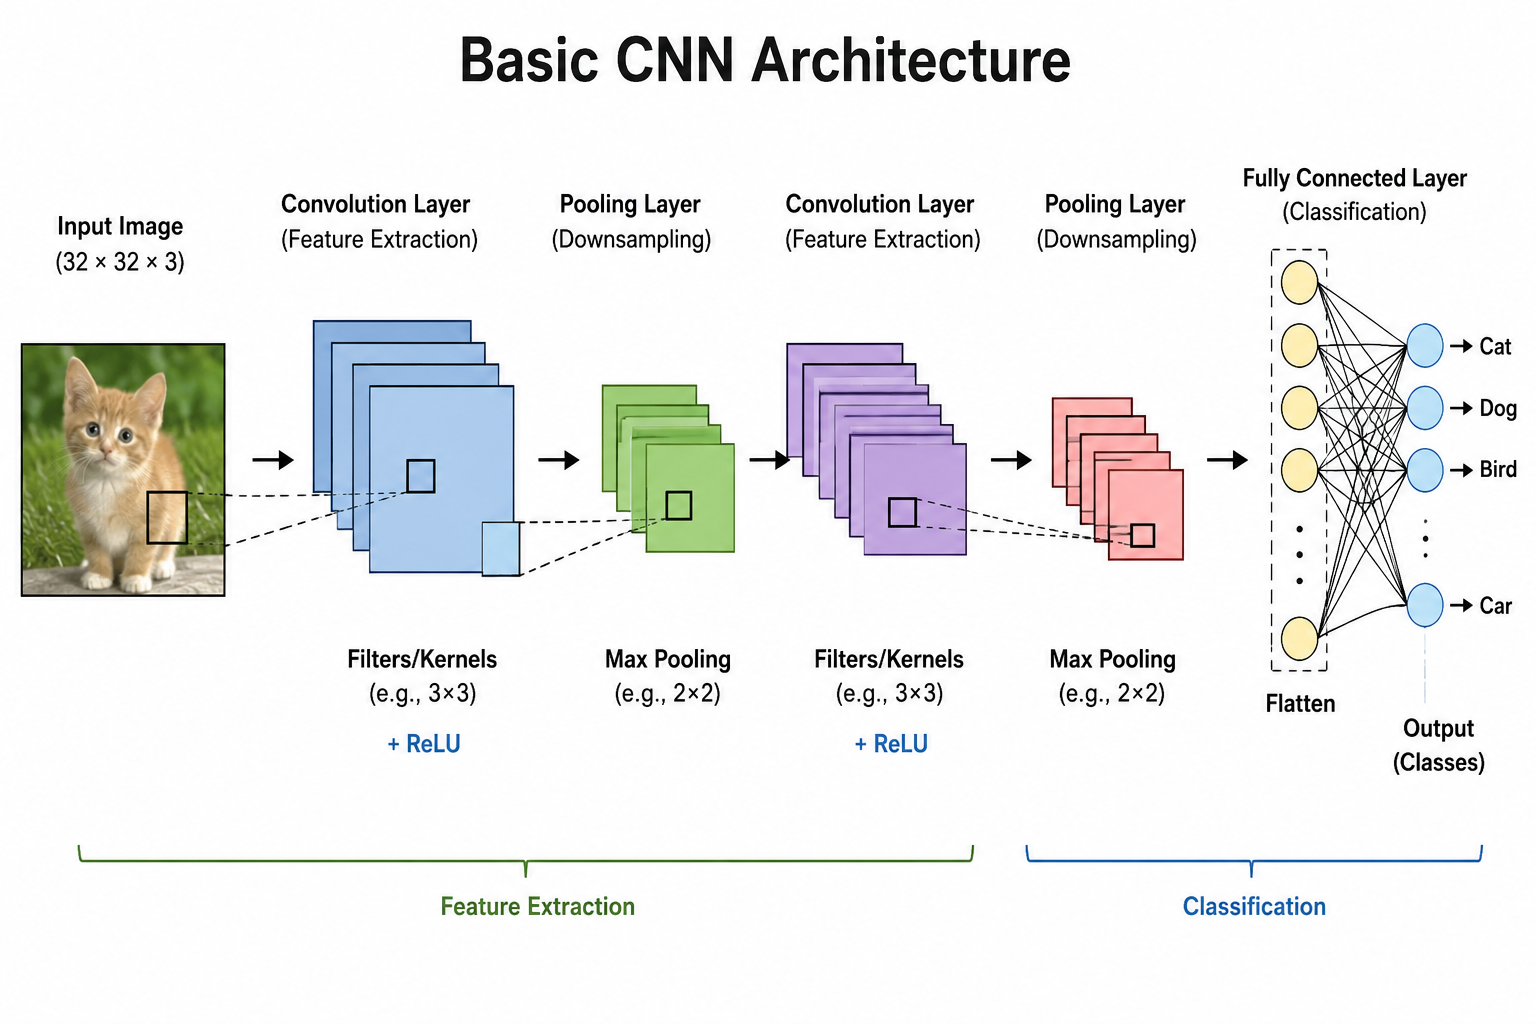
Let's understand each part.

---

#### **Input Layer**

The CNN first receives an image. For example, a grayscale image `28 × 28 × 1`. Where:

* `28` = height
* `28` = width
* `1` = number of channels

For an RGB image `224 × 224 × 3`. The `3` represents:

```text
Red
Green
Blue
```

---

#### **Convolution Layer**

The **Convolution Layer** extracts important features from the image. It uses small filters/kernels. For example:

```text
Input Image
     ↓
┌───────────────┐
│ Convolution   │
│    Filter     │
└───────────────┘
     ↓
Feature Map
```

A small kernel moves across the image:

```text
Input              Kernel

1  2  3  4          1  0
5  6  7  8          0  1
9 10 11 12
13 14 15 16
```

The kernel performs calculations at different positions and produces a **feature map**. Early convolution layers may learn:

* Edges
* Lines
* Corners

Deeper layers can learn:

* Shapes
* Eyes
* Ears
* Wheels
* Faces
* Objects

---

#### **ReLU Activation**

After convolution, we commonly apply **ReLU**. Formula:

$$
ReLU(x)=\max(0,x)
$$

Example:

```text
Before ReLU:     After ReLU:

-3   2   -1      0    2    0
 4  -5    6      4    0    6
```

ReLU removes negative values and introduces **non-linearity**, allowing the network to learn complex patterns.

---

#### **Pooling Layer**

Pooling reduces the spatial size of the feature map. The most common type is **Max Pooling**. For example:

```text
2 × 2 Max Pooling
┌───────┐
│ 1  5  │
│ 7  3  │
└───────┘
Maximum = 7
```

So

```text
1  5
7  3
```

becomes `7`. A larger feature map therefore becomes smaller.

#### **Why use pooling?**

It helps:

* Reduce computation
* Reduce memory usage
* Keep important features
* Make the network less sensitive to small translations

---

#### **Multiple Convolution Blocks**

CNNs usually contain several convolution blocks. As we go deeper, the network generally learns increasingly complex features.

```text
Early layers          Deeper layers

Edges       →         Shapes
Lines       →         Parts
Corners     →         Objects
```

---

#### **Flatten Layer**

After the convolution and pooling layers, we have feature maps. For example:

```text
7 × 7 × 64
```

The **Flatten** layer converts them into a one-dimensional vector:

```text
7 × 7 × 64 -> 3136
```

---

#### **Fully Connected Layer**

The flattened features are passed to one or more **Fully Connected (Linear) layers**. For example:

```text
3136
  ↓
Linear(3136 → 128)
  ↓
ReLU
  ↓
Linear(128 → 10)
```

The fully connected layers use the extracted features to make the final classification.

---

#### **Output Layer**

Suppose we're classifying handwritten digits: `0 1 2 3 4 5 6 7 8 9`. There are **10 output neurons**:

```text
             Output
       ┌─────────────────┐
       │ 0               │
       │ 1               │
       │ 2               │
       │ 3               │
       │ ...             │
       │ 9               │
       └─────────────────┘
```

The network might produce:

```text
0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.90  ← highest
4 → 0.01
...
```

Therefore the prediction is `3`. For multi-class classification, **Softmax** is commonly used to convert logits into class probabilities.

#### **LeNet-5 Architecture**

**LeNet-5** is one of the earliest and most influential **Convolutional Neural Network (CNN)** architectures. It was proposed by **Yann LeCun and colleagues in 1998** for handwritten digit recognition, especially the **MNIST-like 28×28 grayscale digit problem**. The key idea is:

> **Image → Convolution → Pooling → Convolution → Pooling → Fully Connected → Classification**

#### **Complete LeNet-5 Architecture**

The **original LeNet-5** takes a **32 × 32 grayscale image**.

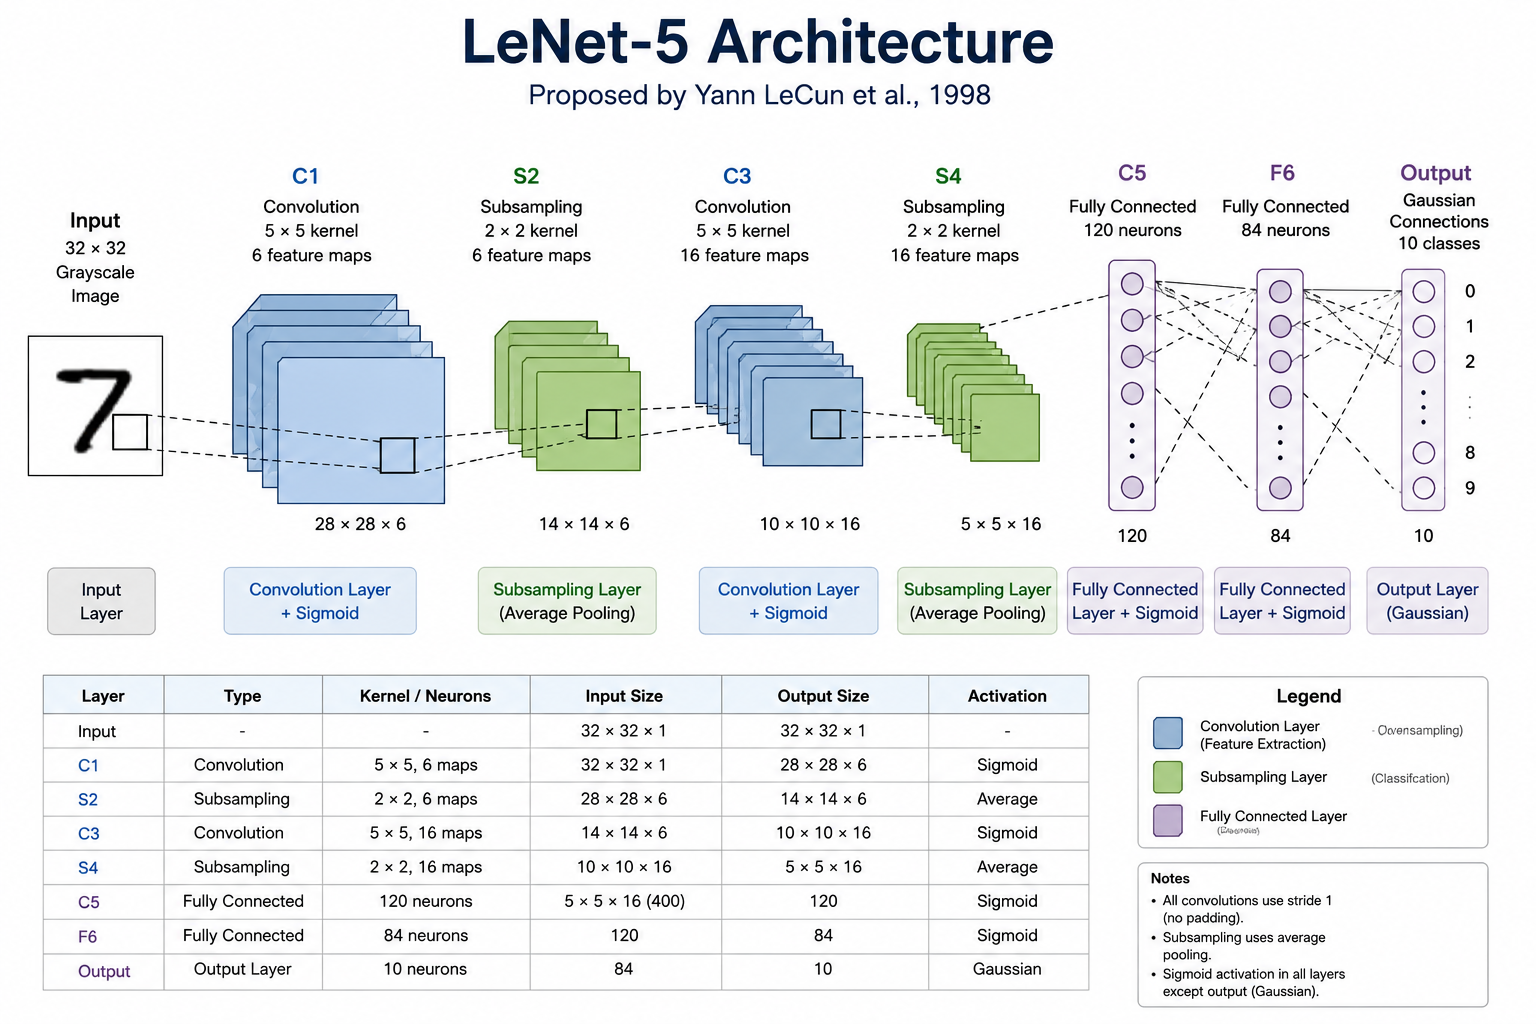

---

#### **Layer-by-Layer Explanation**

**Input — 32 × 32 × 1:** The original LeNet-5 was designed for:

```text
Height = 32
Width  = 32
Channels = 1
```

So `32 × 32 × 1`. The `1` means it is a **grayscale** image.

---

**C1 — First Convolution Layer:** The first convolution layer contains:

```text
6 filters
5 × 5 kernel
```

Therefore:

```text
Input: 32 × 32 × 1 -> Conv 5×5 -> Output: 28 × 28 × 6
```

Why `28 × 28`?

$$
Output = \frac{N-F}{S}+1
$$

where:

* $N=32$
* $F=5$
* $S=1$

Therefore:
$$
\frac{32-5}{1}+1=28
$$

So the output is `28 × 28 × 6`. The six filters learn different features such as:

```text
Filter 1 → edges
Filter 2 → vertical patterns
Filter 3 → horizontal patterns
Filter 4 → curves
...
Filter 6 → other patterns
```

---

**S2 — Subsampling / Pooling:** The original LeNet-5 used a **subsampling layer** which is conceptually similar to pooling. It reduces: `28 × 28 × 6 to 14 × 14 × 6`. Using:

```text
2 × 2
Stride = 2
```

So `28 × 28 -> 14 × 14`. The number of feature maps remains `6`. Therefore `14 × 14 × 6`. 

---

**C3 — Second Convolution Layer:** Now the network performs another convolution.

```text
Input: 14 × 14 × 6 -> Conv 5×5 -> Output: 10 × 10 × 16
```

There are 16 feature maps. The spatial size becomes `14-5+1=10`. Therefore `10 × 10 × 16`.

**Important:** The second convolution layer works on the features extracted by the first convolution layer. So the network is gradually learning more complex patterns.

---

**S4 — Second Pooling Layer:** Again, the feature maps are reduced.

```text
10 × 10 × 16 -> Pooling -> 5 × 5 × 16
```

The spatial dimensions are divided by 2. So the output is `5 × 5 × 16`.

---

**C5 — Third Convolution Layer:** Now comes an interesting part of LeNet-5. The input is `5 × 5 × 16`. The convolution kernel is `5 × 5`. Because the kernel covers the entire `5 × 5` spatial area:

```text
5 × 5 × 16 -> 5 × 5 convolution -> 1 × 1
```

There are **120 filters**. Therefore `5 × 5 × 16 -> 1 × 1 × 120`. This can essentially be viewed as `120 features`. 

---

**F6 — Fully Connected Layer:** The C5 output contains `1 × 1 × 120` which gives `120 values`. These are connected to `84 neurons`. So `120 -> 84`. This layer combines the extracted features to help determine which digit is present.

---

**Output Layer:** Finally `84 -> 120`. There are **10 output units**, corresponding to **0 1 2 3 4 5 6 7 8 9**. For example:

```text
Output probabilities:
0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.89  ← highest
4 → 0.01
...
```

Prediction **3**. 

---

#### **LeNet-5 Architecture Implementation in PyTorch**

Let's implement the **classic LeNet-5 architecture** in PyTorch step by step.

> **Note:** The original LeNet-5 uses a `32×32` input and has some historical differences from the simplified versions commonly implemented today. We'll implement the classic structure in a way that's easy to understand and use.

#### **Import PyTorch**

In [1]:
import torch
import torch.nn as nn

---

#### **Define the LeNet-5 Model**

In [2]:
class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()

        # C1: Convolution Layer
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5
        )

        # S2: Pooling Layer
        self.pool1 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # C3: Convolution Layer
        self.conv2 = nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=5
        )

        # S4: Pooling Layer
        self.pool2 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # C5: Convolution Layer
        self.conv3 = nn.Conv2d(
            in_channels=16,
            out_channels=120,
            kernel_size=5
        )

        # F6: Fully Connected Layer
        self.fc1 = nn.Linear(
            in_features=120,
            out_features=84
        )

        # Output Layer
        self.fc2 = nn.Linear(
            in_features=84,
            out_features=10
        )

    def forward(self, x):

        # C1 → S2
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)

        # C3 → S4
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        # C5
        x = torch.relu(self.conv3(x))

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # F6
        x = torch.relu(self.fc1(x))

        # Output
        x = self.fc2(x)

        return x

---

#### **Create the Model**

In [3]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


---

#### **Test the Model with a Dummy Image**

Let's give the network one `32×32` grayscale image.

In [4]:
x = torch.randn(1, 1, 32, 32)
output = model(x)

print("Input shape :", x.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([1, 1, 32, 32])
Output shape: torch.Size([1, 10])


Here:

```text
1 → batch size
1 → grayscale channel
32 → height
32 → width
```

And [1, 10] means For this one image, the model produced **10 values** one for each digit from `0` to `9`.

---

#### **Why `torch.flatten()`?**

After the last convolution `1 × 1 × 120` We need to send the result to a fully connected layer. So

```python
x = torch.flatten(x, start_dim=1)
```

changes [batch, 120, 1, 1] into [batch, 120]. For example:

```text
Before [32, 120, 1, 1] -> flatten -> [32, 120]
```

The `32` is the batch size.

---

#### **Why No Softmax?**

Notice that we didn't write:

```python
x = torch.softmax(x, dim=1)
```

That's intentional. When training a multi-class classifier in PyTorch, we normally use:

```python
criterion = nn.CrossEntropyLoss()
```

`CrossEntropyLoss` expects **raw logits**, so we don't need to apply Softmax inside the model.

---